In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("BankCustomerData.csv")

In [16]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42634,21,student,single,secondary,no,2488,no,no,telephone,12,jan,661,2,92,1,success,yes
42635,87,retired,married,primary,no,2190,no,no,telephone,12,jan,512,2,-1,0,unknown,yes
42636,34,blue-collar,married,primary,no,6718,no,no,cellular,13,jan,278,4,97,1,other,no
42637,22,student,single,secondary,no,254,no,no,cellular,13,jan,143,2,-1,0,unknown,yes


In [17]:
df.dtypes

age              int64
job             object
marital         object
education       object
default         object
balance          int64
housing         object
loan            object
contact         object
day              int64
month           object
duration         int64
campaign         int64
pdays            int64
previous         int64
poutcome        object
term_deposit    object
dtype: object

In [18]:
df.shape

(42639, 17)

In [19]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [22]:
df["job"] = df["job"].str.title()
df["marital"] = df["marital"].str.title()
df["education"] = df["education"].str.title()
df["default"] = df["default"].str.title()
df["housing"] = df["housing"].str.title()
df["loan"] = df["loan"].str.title()
df["contact"] = df["contact"].str.title()
df["month"] = df["month"].str.title()
df["poutcome"] = df["poutcome"].str.title()
df["term_deposit"] = df["term_deposit"].str.title()

In [23]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit
0,58,Management,Married,Tertiary,No,2143,Yes,No,Unknown,5,May,261,1,-1,0,Unknown,No
1,44,Technician,Single,Secondary,No,29,Yes,No,Unknown,5,May,151,1,-1,0,Unknown,No
2,33,Entrepreneur,Married,Secondary,No,2,Yes,Yes,Unknown,5,May,76,1,-1,0,Unknown,No
3,47,Blue-Collar,Married,Unknown,No,1506,Yes,No,Unknown,5,May,92,1,-1,0,Unknown,No
4,33,Unknown,Single,Unknown,No,1,No,No,Unknown,5,May,198,1,-1,0,Unknown,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42634,21,Student,Single,Secondary,No,2488,No,No,Telephone,12,Jan,661,2,92,1,Success,Yes
42635,87,Retired,Married,Primary,No,2190,No,No,Telephone,12,Jan,512,2,-1,0,Unknown,Yes
42636,34,Blue-Collar,Married,Primary,No,6718,No,No,Cellular,13,Jan,278,4,97,1,Other,No
42637,22,Student,Single,Secondary,No,254,No,No,Cellular,13,Jan,143,2,-1,0,Unknown,Yes


In [24]:
cat_cols = ["job", "marital", "education",	"default", "housing", "loan", "month",	"poutcome",	"term_deposit"]
for col in cat_cols:
    df[col] = df[col].astype("category")

In [25]:
df["term_deposit"] = df["term_deposit"].str.strip().str.lower()
df["term_deposit"] = df["term_deposit"].map({"yes": 1, "no": 0})

In [26]:
months_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df["month"] = pd.Categorical(df["month"], categories = months_order, ordered = True)

In [27]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit
0,58,Management,Married,Tertiary,No,2143,Yes,No,Unknown,5,May,261,1,-1,0,Unknown,0
1,44,Technician,Single,Secondary,No,29,Yes,No,Unknown,5,May,151,1,-1,0,Unknown,0
2,33,Entrepreneur,Married,Secondary,No,2,Yes,Yes,Unknown,5,May,76,1,-1,0,Unknown,0
3,47,Blue-Collar,Married,Unknown,No,1506,Yes,No,Unknown,5,May,92,1,-1,0,Unknown,0
4,33,Unknown,Single,Unknown,No,1,No,No,Unknown,5,May,198,1,-1,0,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42634,21,Student,Single,Secondary,No,2488,No,No,Telephone,12,Jan,661,2,92,1,Success,1
42635,87,Retired,Married,Primary,No,2190,No,No,Telephone,12,Jan,512,2,-1,0,Unknown,1
42636,34,Blue-Collar,Married,Primary,No,6718,No,No,Cellular,13,Jan,278,4,97,1,Other,0
42637,22,Student,Single,Secondary,No,254,No,No,Cellular,13,Jan,143,2,-1,0,Unknown,1


In [28]:
df.isnull().sum()

age             0
job             0
marital         0
education       0
default         0
balance         0
housing         0
loan            0
contact         0
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome        0
term_deposit    0
dtype: int64

## Exploratory Data Analysis

### 1. Which customers are more likely to subscribe to a term deposit?

In [29]:
# Value counts
print(df["term_deposit"].value_counts())

# Groupby and describe
print(df.groupby("term_deposit")[["age", "balance"]].describe())

term_deposit
0    38678
1     3961
Name: count, dtype: int64
                  age                                                      \
                count       mean        std   min   25%   50%   75%   max   
term_deposit                                                                
0             38678.0  40.759010   9.917136  18.0  33.0  39.0  48.0  95.0   
1              3961.0  41.079778  12.633397  18.0  31.0  38.0  49.0  95.0   

              balance                                                          \
                count         mean          std     min    25%    50%     75%   
term_deposit                                                                    
0             38678.0  1286.736646  2970.302970 -8019.0   54.0  407.0  1323.0   
1              3961.0  1772.518808  3356.580982 -3058.0  178.0  699.0  2112.0   

                        
                   max  
term_deposit            
0             102127.0  
1              81204.0  


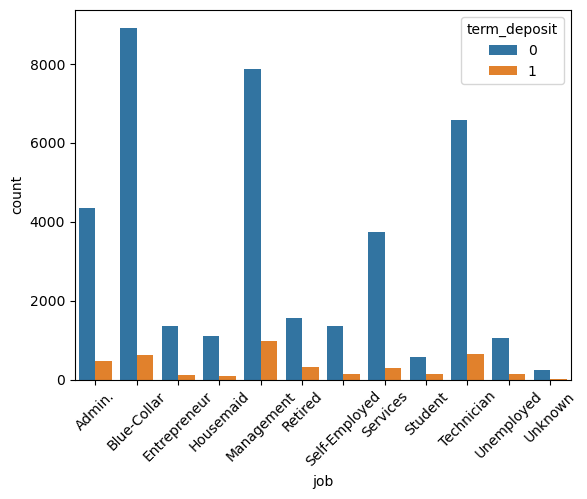

In [42]:
# Countplots
sns.countplot(x = "job", hue = "term_deposit", data=df)
plt.xticks(rotation=45)
plt.show()

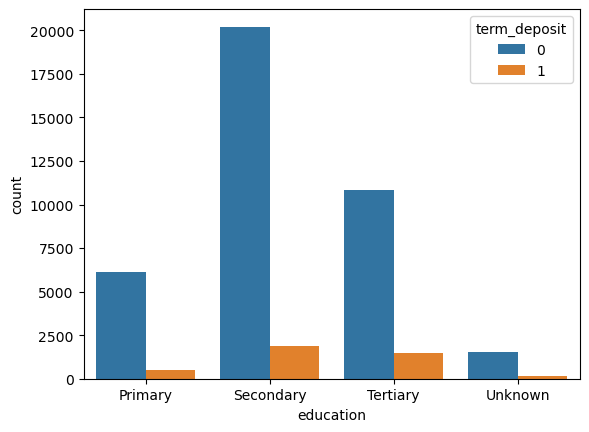

In [32]:
sns.countplot(x = "education", hue = "term_deposit", data=df)
plt.show()

### 2. What customer characteristics increase conversation rate?

In [43]:
# Education distribution by term_deposit
print(df.groupby("term_deposit")["education"].value_counts(normalize=True))

# Correlation with balance
print(df[["age", "balance", "duration", "campaign", "pdays", "previous"]].corr())

term_deposit  education
0             Secondary    0.522468
              Tertiary     0.280056
              Primary      0.157893
              Unknown      0.039583
1             Secondary    0.469073
              Tertiary     0.371118
              Primary      0.119667
              Unknown      0.040141
Name: proportion, dtype: float64
               age   balance  duration  campaign     pdays  previous
age       1.000000  0.088716 -0.016529  0.008296 -0.044165 -0.016279
balance   0.088716  1.000000  0.016721 -0.013358 -0.006797  0.005194
duration -0.016529  0.016721  1.000000 -0.085640 -0.010812 -0.007730
campaign  0.008296 -0.013358 -0.085640  1.000000 -0.079981 -0.024374
pdays    -0.044165 -0.006797 -0.010812 -0.079981  1.000000  0.450869
previous -0.016279  0.005194 -0.007730 -0.024374  0.450869  1.000000


### 3. Which factors make customers reject the offer?

In [35]:
# Factors leading to rejection 
print(df[df["term_deposit"]== "no"].describe())

       age  balance  day  duration  campaign  pdays  previous  term_deposit
count  0.0      0.0  0.0       0.0       0.0    0.0       0.0           0.0
mean   NaN      NaN  NaN       NaN       NaN    NaN       NaN           NaN
std    NaN      NaN  NaN       NaN       NaN    NaN       NaN           NaN
min    NaN      NaN  NaN       NaN       NaN    NaN       NaN           NaN
25%    NaN      NaN  NaN       NaN       NaN    NaN       NaN           NaN
50%    NaN      NaN  NaN       NaN       NaN    NaN       NaN           NaN
75%    NaN      NaN  NaN       NaN       NaN    NaN       NaN           NaN
max    NaN      NaN  NaN       NaN       NaN    NaN       NaN           NaN


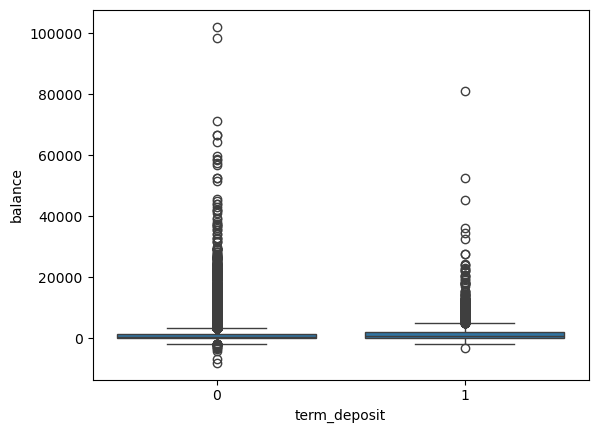

In [36]:
# Compare loan, housing, balance distributions
sns.boxplot(x = "term_deposit", y = "balance", data=df)
plt.show()

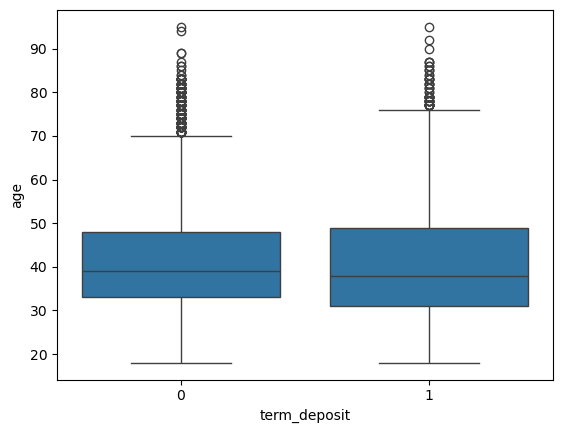

In [37]:
# 4. Does age affect subscription?
sns.boxplot(x = "term_deposit", y = "age", data=df)
plt.show()

In [44]:
# 5. Which job types subscribe more?
print(df.groupby("job")["term_deposit"].value_counts(normalize=True).unstack())

term_deposit          0         1
job                              
Admin.         0.903119  0.096881
Blue-Collar    0.936032  0.063968
Entrepreneur   0.928424  0.071576
Housemaid      0.931239  0.068761
Management     0.890408  0.109592
Retired        0.829255  0.170745
Self-Employed  0.902000  0.098000
Services       0.925118  0.074882
Student        0.788301  0.211699
Technician     0.910425  0.089575
Unemployed     0.885163  0.114837
Unknown        0.909091  0.090909


C:\Users\Eniholla\AppData\Local\Temp\ipykernel_13064\1134320621.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("job")["term_deposit"].value_counts(normalize=True).unstack())


In [45]:
# 6. Does education level influence decisions?
print(df.groupby("education")["term_deposit"].value_counts(normalize=True).unstack())

term_deposit         0         1
education                       
Primary       0.927974  0.072026
Secondary     0.915798  0.084202
Tertiary      0.880507  0.119493
Unknown       0.905917  0.094083


C:\Users\Eniholla\AppData\Local\Temp\ipykernel_13064\2672274147.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("education")["term_deposit"].value_counts(normalize=True).unstack())


In [46]:
# 7. Are married vs single customers behaving differently?
print(df.groupby("marital")["term_deposit"].value_counts(normalize=True).unstack())

term_deposit         0         1
marital                         
Divorced      0.898489  0.101511
Married       0.920210  0.079790
Single        0.882009  0.117991


C:\Users\Eniholla\AppData\Local\Temp\ipykernel_13064\3531827195.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("marital")["term_deposit"].value_counts(normalize=True).unstack())


## Visualization

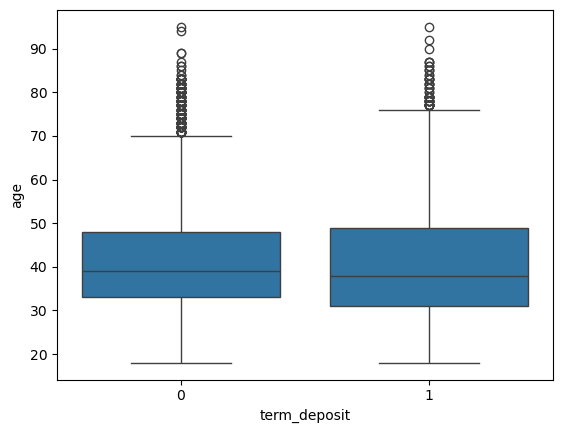

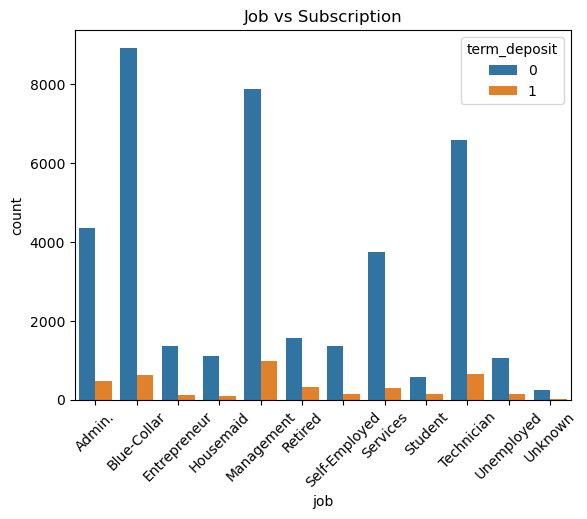

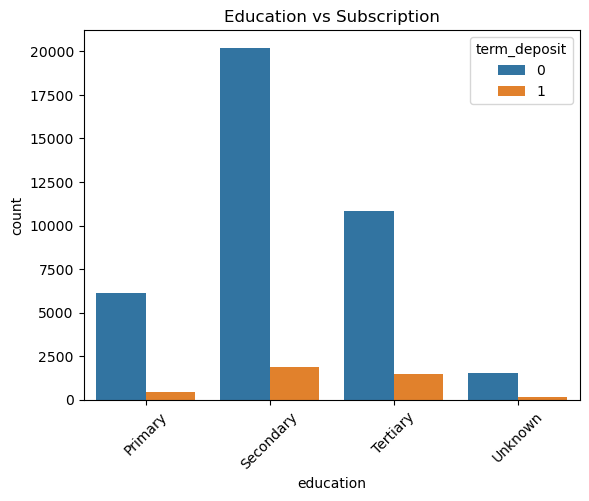

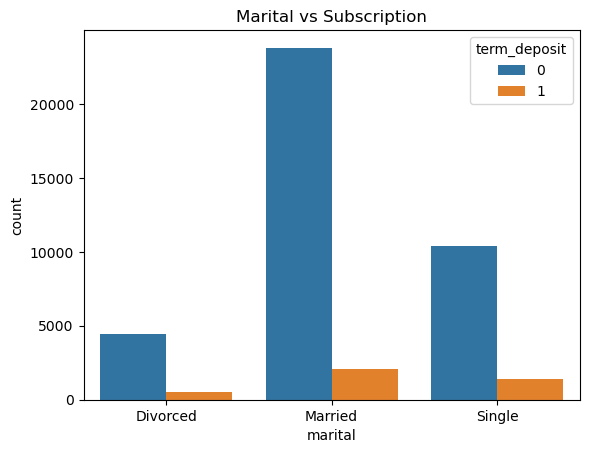

In [41]:
sns.boxplot(x = "term_deposit", y = "age", data=df)
plt.show()

sns.countplot(x = "job", hue = "term_deposit", data=df)
plt.title("Job vs Subscription")
plt.xticks(rotation=45)
plt.show()

sns.countplot(x = "education", hue = "term_deposit", data=df)
plt.title("Education vs Subscription")
plt.xticks(rotation=45)
plt.show()

sns.countplot(x = "marital", hue = "term_deposit", data=df)
plt.title("Marital vs Subscription")
plt.show()

## Insights:
- Age : The age distribution of customers who subscribe and those who did not is very similar
- Job : Blue-Collar, Management and Technician subscribe more
- Education: Secondary-educated people subscribe more
- Marital: Married people subscribe more 